In [19]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
def get_color_map_list(num_classes):
    """
    Returns the color map for visualizing the segmentation mask,
    which can support arbitrary number of classes.
    Args:
        num_classes (int): Number of classes.
    Returns:
        (list). The color map.
    """

    num_classes += 1
    color_map = num_classes * [0, 0, 0]
    for i in range(0, num_classes):
        j = 0
        lab = i
        while lab:
            color_map[i * 3] |= (((lab >> 0) & 1) << (7 - j))
            color_map[i * 3 + 1] |= (((lab >> 1) & 1) << (7 - j))
            color_map[i * 3 + 2] |= (((lab >> 2) & 1) << (7 - j))
            j += 1
            lab >>= 3
    color_map = color_map[3:]
    return color_map

In [4]:
_path1 = 'E:\\dataset\\tok\\JPEGImages\\annotations\\12.png'
image = Image.open(_path1)
image = np.array(image)
print(image.shape)

(1057, 634)


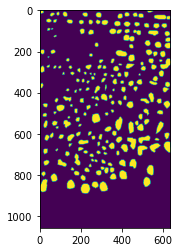

In [5]:
plt.imshow(image)

In [6]:
print(image[850, 20])

1


In [7]:
_path2 = 'E:\\dataset\\tok\\JPEGImages\\12.png'
image_src = cv2.imread(_path2)
print(image_src.shape)

(1057, 634, 3)


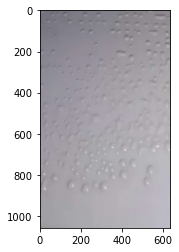

In [8]:
plt.imshow(cv2.cvtColor(image_src,cv2.COLOR_BGR2RGB))

In [9]:
_average_colors = image_src[950:1050, 400:600,:]
average_color = _average_colors.reshape(-1,3)

In [10]:
_len = len(average_color)
average_color = average_color.astype(np.float32)
average_color = np.sum(average_color, axis=0)/_len
average_color = average_color.astype(np.uint8)


In [11]:
random_rect = []
for _i in range(0, 820):
    for _j in range(0, 400):
        _height = np.random.randint(100, image.shape[0]-_i-2) # 随机框的高
        _width = np.random.randint(100, image.shape[1]-_j-2) # 随机框的高
        random_rect.append([_i, _j, _height, _width])
random_rect = np.array(random_rect)

In [17]:
random_rect_part = random_rect[0:1000]

In [13]:
save_src_path = "E:\\dataset\\tok1\\leftImg8bit"
save_mask_path = "E:\\dataset\\tok1\\gtFine"

In [15]:
color_map = get_color_map_list(256)

In [18]:
_new_img_src = np.full_like(image_src, average_color, dtype=np.uint8) # 生成背景图
_new_img_mask_src = np.full_like(image, 0, dtype=np.uint8) # 生成背景图
for i in range(0, len(random_rect_part)):
    rect = random_rect_part[i]
    _i_src = rect[0]
    _height = rect[2]
    if _height > 300:
        _height = 300
    _i = np.random.randint(0, image_src.shape[0]-_height) # 新的随机y坐标
    _j_src = rect[1]
    _width = rect[3]
    if _width > 200:
        _width = 200
    _j = np.random.randint(0, image_src.shape[1]-_width) # 新的随机x坐标

    new_img = _new_img_src.copy()
    new_img[_i:_i+_height, _j:_j+_width, :] = image_src[_i_src:_i_src+_height, _j_src:_j_src+_width, :]
    cv2.imwrite(os.path.join(save_src_path, str(i+1)+".jpg"), new_img)

    new_img_mask = _new_img_mask_src.copy() # 生成背景图
    new_img_mask[_i:_i+_height, _j:_j+_width] = image[_i_src:_i_src+_height, _j_src:_j_src+_width]

    lbl_pil = Image.fromarray(new_img_mask.astype(np.uint8), mode='P')
    lbl_pil.putpalette(color_map)
    lbl_pil.save(os.path.join(save_mask_path, str(i+1)+".png"))

